# Crowd Counting with CNN on JHU-Crowd v2.0 
**Dataset:** JHU-Crowd v2.0 a large-scale crowd counting benchmark containing 4,372 images with over 1.5 million annotations, spanning a diverse range of weather conditions, illumination levels, and scene types.

---

## 1. Setup & Imports


In [1]:
import os, glob, random, warnings, zipfile, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from pathlib import Path
from tqdm.auto import tqdm
from scipy.ndimage import gaussian_filter

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.applications import VGG16

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

2026-05-11 13:39:33.540589: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778506773.758037      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778506773.823371      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778506774.397599      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778506774.397639      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778506774.397642      23 computation_placer.cc:177] computation placer alr

---
## 2. Data Download & Extraction

The JHU-Crowd v2.0 dataset is stored on Google Drive. So we use the **Google Drive file ID** to stream it directly into the this environment

In [2]:
import subprocess

FILE_ID   = "1Rc4WXCONB7XeR024uOWWFzp_SZjyAdGc"  # Dataset file ID
ZIP_PATH  = "/kaggle/working/jhu_crowd_v2.0.zip"
DATA_ROOT = "/kaggle/working/jhu_crowd_v2.0"

if not os.path.exists(DATA_ROOT):
    print("Downloading dataset from Google Drive …")
    subprocess.run(
        ["gdown", "--id", FILE_ID, "-O", ZIP_PATH],
        check=True
    )
    print("Extracting …")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall("/kaggle/working/")
    print("Done ✓")
else:
    print("Dataset already present ✓")

# Verify directory tree
for split in ["train", "val", "test"]:
    imgs = glob.glob(f"{DATA_ROOT}/{split}/images/*.jpg")
    gts  = glob.glob(f"{DATA_ROOT}/{split}/gt/*.txt")
    print(f"  {split:6s}: {len(imgs):4d} images | {len(gts):4d} ground-truth files")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Rc4WXCONB7XeR024uOWWFzp_SZjyAdGc
From (redirected): https://drive.google.com/uc?id=1Rc4WXCONB7XeR024uOWWFzp_SZjyAdGc&confirm=t&uuid=818976b3-74a1-4c83-a540-3a4361f342be
To: /kaggle/working/jhu_crowd_v2.0.zip
100%|██████████| 3.08G/3.08G [00:32<00:00, 94.2MB/s]


Extracting …
Done ✓
  train : 2272 images | 2272 ground-truth files
  val   :  500 images |  500 ground-truth files
  test  : 1600 images | 1600 ground-truth files


---
## 3. Exploratory Data Analysis

In [3]:
# 3.1  Parse all annotation files
def load_gt_points(txt_path):
    """Return Nx2 array of (x, y) head locations from a JHU-Crowd annotation file."""
    pts = []
    with open(txt_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                pts.append((float(parts[0]), float(parts[1])))
    return np.array(pts) if pts else np.zeros((0, 2))

records = []
for split in ["train", "val", "test"]:
    gt_files = sorted(glob.glob(f"{DATA_ROOT}/{split}/gt/*.txt"))
    for gt in gt_files:
        stem   = Path(gt).stem
        img_p  = f"{DATA_ROOT}/{split}/images/{stem}.jpg"
        pts    = load_gt_points(gt)
        count  = len(pts)
        if os.path.exists(img_p):
            h, w, _ = cv2.imread(img_p).shape
            records.append({"split": split, "stem": stem,
                            "count": count, "height": h, "width": w,
                            "img_path": img_p, "gt_path": gt})

df = pd.DataFrame(records)
print(df.groupby("split")[["count"]].describe().round(1))

        count                                                 
        count   mean     std  min   25%    50%    75%      max
split                                                         
test   1600.0  326.2   723.3  0.0  45.8  117.5  299.2   9059.0
train  2272.0  371.8  1129.5  0.0  45.0  111.0  279.0  25791.0
val     500.0  297.0   672.6  2.0  38.0   94.5  240.5   5929.0


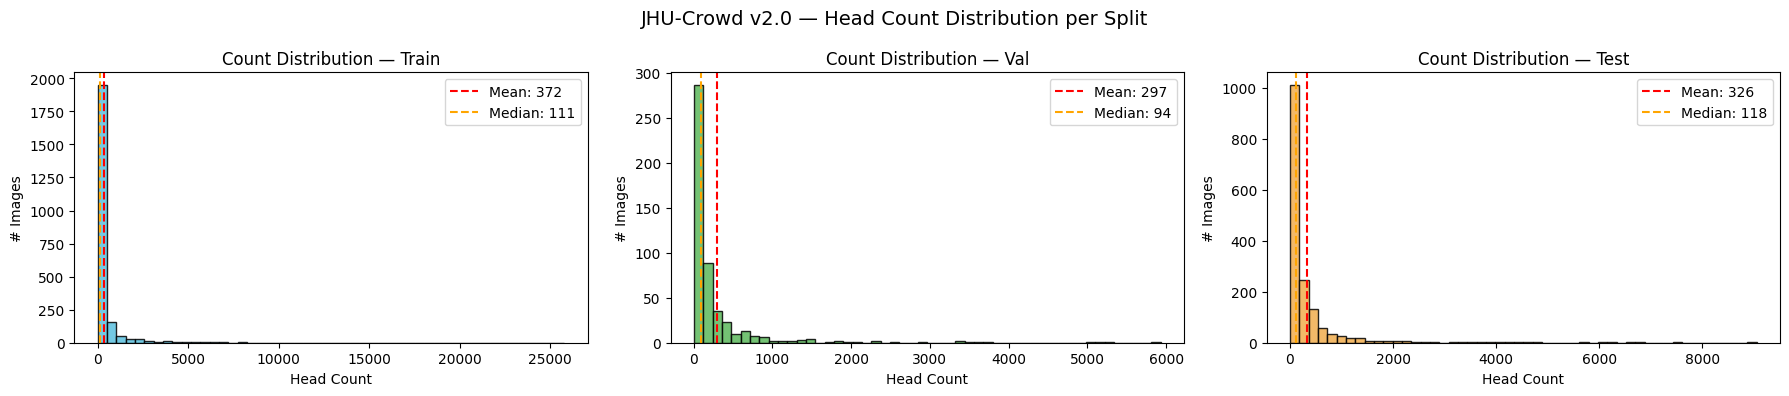

In [4]:
# 3.2  Count distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colors = {"train": "#5bc0de", "val": "#5cb85c", "test": "#f0ad4e"}

for ax, split in zip(axes, ["train", "val", "test"]):
    sub = df[df["split"] == split]["count"]
    ax.hist(sub, bins=50, color=colors[split], edgecolor="black", alpha=0.85)
    ax.axvline(sub.mean(),   color="red",    linestyle="--", label=f"Mean: {sub.mean():.0f}")
    ax.axvline(sub.median(), color="orange", linestyle="--", label=f"Median: {sub.median():.0f}")
    ax.set_title(f"Count Distribution — {split.capitalize()}", fontsize=12)
    ax.set_xlabel("Head Count"); ax.set_ylabel("# Images")
    ax.legend()

plt.suptitle("JHU-Crowd v2.0 — Head Count Distribution per Split", fontsize=14)
plt.tight_layout(); plt.show()

# Insight: right-skewed distribution; density-map regression captures spatial info.

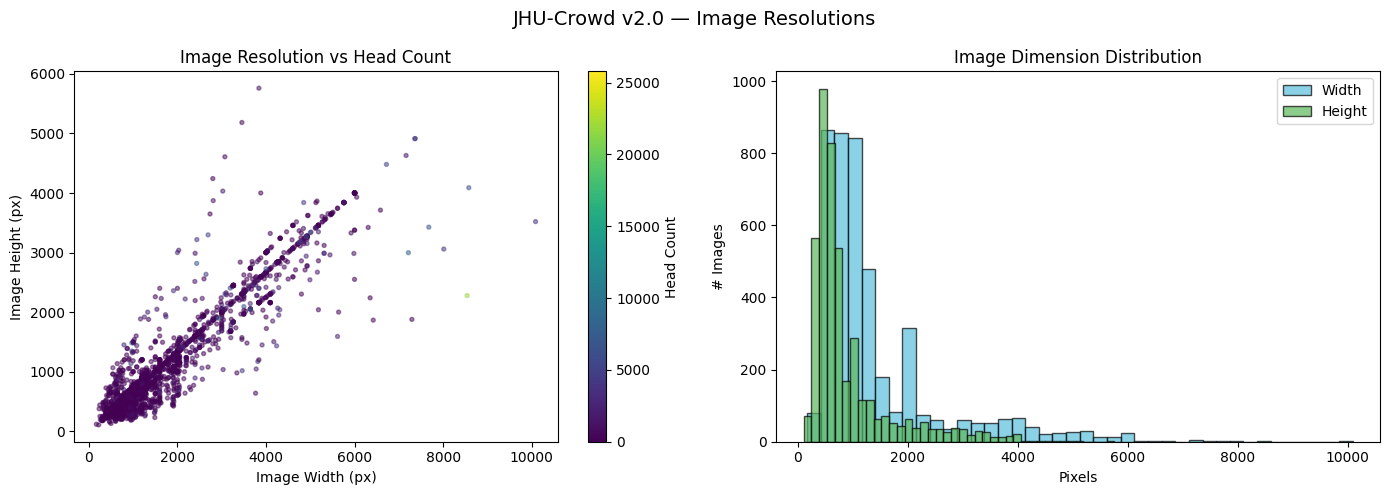

Width  stats: {'count': 4372.0, 'mean': 1431.0, 'std': 1172.0, 'min': 169.0, '25%': 717.0, '50%': 1000.0, '75%': 1600.0, 'max': 10088.0}
Height stats: {'count': 4372.0, 'mean': 910.0, 'std': 771.0, 'min': 107.0, '25%': 440.0, '50%': 630.0, '75%': 1051.0, 'max': 5760.0}


In [5]:
# 3.3  Image resolution heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["width"], df["height"],
                c=df["count"], cmap="viridis", alpha=0.5, s=8)
sm = plt.cm.ScalarMappable(cmap="viridis",
     norm=plt.Normalize(df["count"].min(), df["count"].max()))
plt.colorbar(sm, ax=axes[0], label="Head Count")
axes[0].set_xlabel("Image Width (px)"); axes[0].set_ylabel("Image Height (px)")
axes[0].set_title("Image Resolution vs Head Count")

axes[1].hist(df["width"],  bins=40, alpha=0.7, label="Width",  color="#5bc0de", edgecolor="black")
axes[1].hist(df["height"], bins=40, alpha=0.7, label="Height", color="#5cb85c", edgecolor="black")
axes[1].set_xlabel("Pixels"); axes[1].set_ylabel("# Images")
axes[1].set_title("Image Dimension Distribution"); axes[1].legend()

plt.suptitle("JHU-Crowd v2.0 — Image Resolutions", fontsize=14)
plt.tight_layout(); plt.show()

print("Width  stats:", df["width"].describe().round(0).to_dict())
print("Height stats:", df["height"].describe().round(0).to_dict())

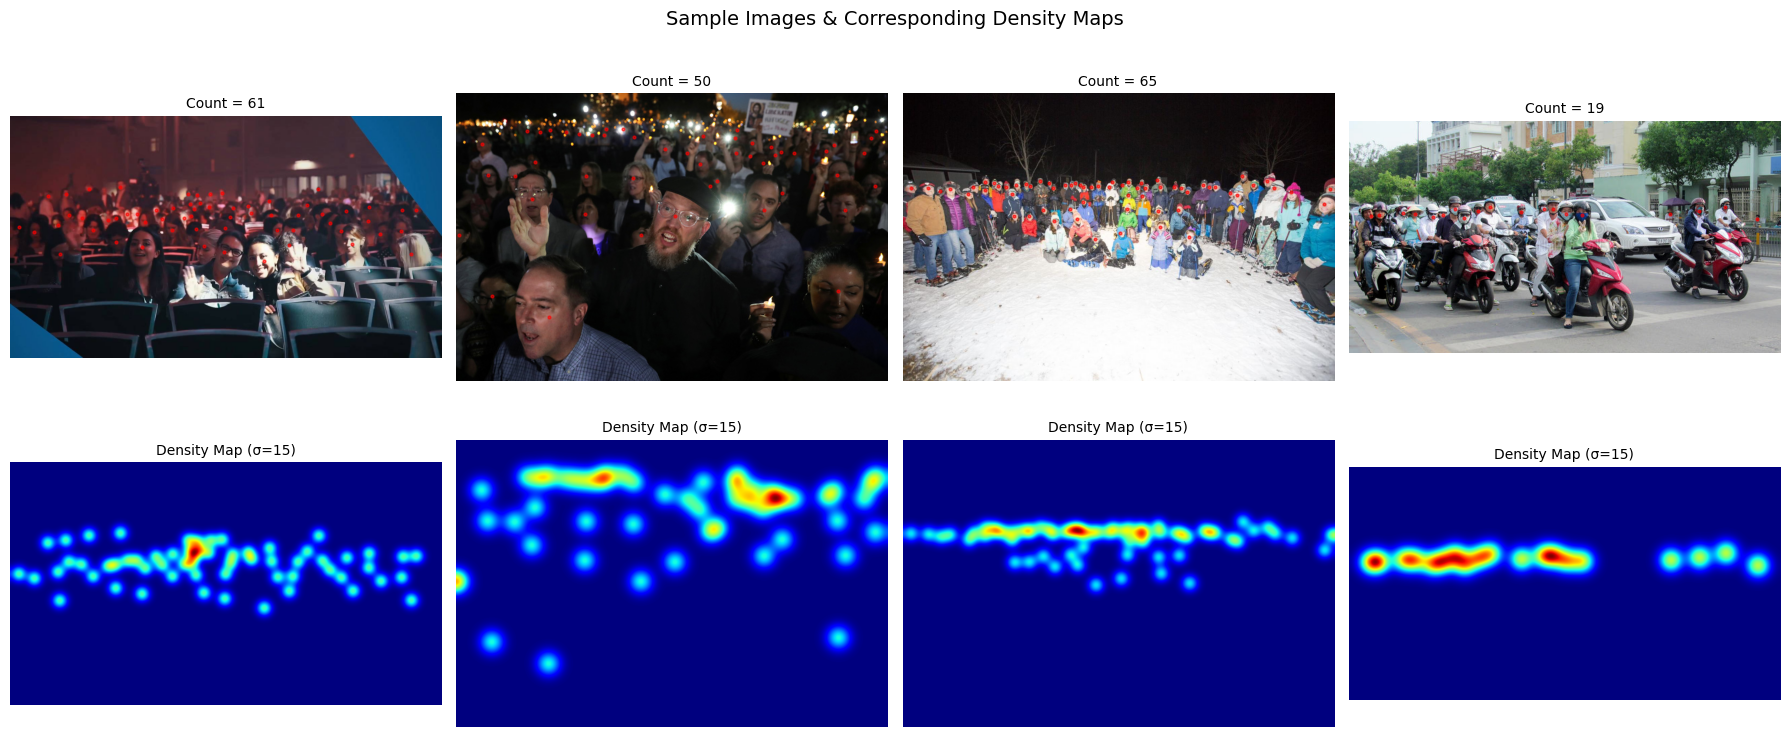

In [6]:
# 3.4  Sample crowd images with annotations
sample = df[df["split"] == "train"].sample(4, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, (_, row) in enumerate(sample.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    pts = load_gt_points(row["gt_path"])

    axes[0, i].imshow(img)
    if len(pts):
        axes[0, i].scatter(pts[:, 0], pts[:, 1], s=4, c="red", alpha=0.6)
    axes[0, i].set_title(f"Count = {row['count']}", fontsize=10)
    axes[0, i].axis("off")

    # density map preview
    dmap = np.zeros(img.shape[:2], dtype=np.float32)
    if len(pts):
        for x, y in pts:
            xi, yi = int(np.clip(x, 0, img.shape[1]-1)), int(np.clip(y, 0, img.shape[0]-1))
            dmap[yi, xi] += 1
        dmap = gaussian_filter(dmap, sigma=15)
    axes[1, i].imshow(dmap, cmap="jet")
    axes[1, i].set_title(f"Density Map (σ=15)", fontsize=10)
    axes[1, i].axis("off")

plt.suptitle("Sample Images & Corresponding Density Maps", fontsize=14)
plt.tight_layout(); plt.show()

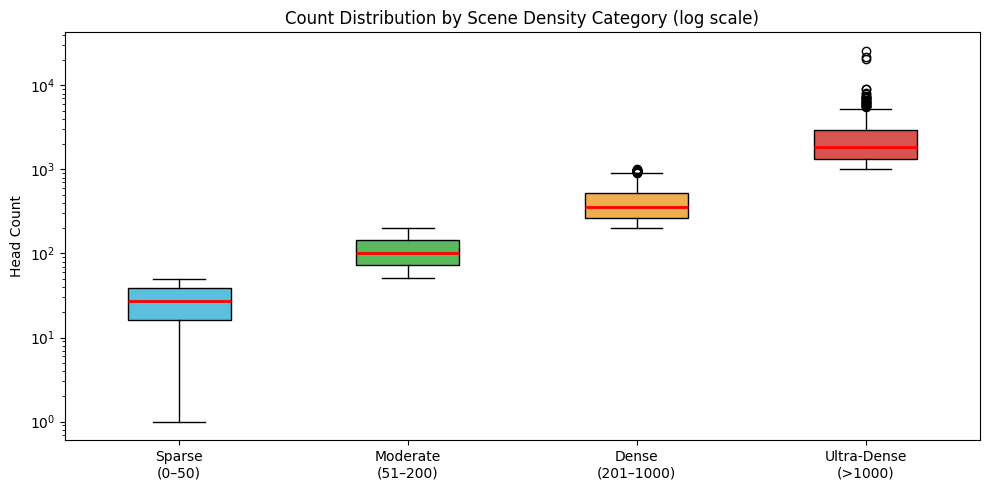

Category distribution:
density_cat
Sparse\n(0–50)          1243
Moderate\n(51–200)      1681
Dense\n(201–1000)       1129
Ultra-Dense\n(>1000)     313
Name: count, dtype: int64


In [7]:
# 3.5  Count vs. Scene Density Box-Plot
bins   = [0, 50, 200, 1000, df["count"].max() + 1]
labels = ["Sparse\n(0–50)", "Moderate\n(51–200)", "Dense\n(201–1000)", "Ultra-Dense\n(>1000)"]
df["density_cat"] = pd.cut(df["count"], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(10, 5))
groups  = [df[df["density_cat"] == l]["count"].values for l in labels]
bp = ax.boxplot(groups, labels=labels, patch_artist=True,
                medianprops=dict(color="red", linewidth=2))
palette = ["#5bc0de", "#5cb85c", "#f0ad4e", "#d9534f"]
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)

ax.set_ylabel("Head Count"); ax.set_yscale("log")
ax.set_title("Count Distribution by Scene Density Category (log scale)", fontsize=12)
plt.tight_layout(); plt.show()

print("Category distribution:")
print(df["density_cat"].value_counts().sort_index())

---
## 4. Preprocessing

### 4.1 Why Do We Normalise?

Neural networks learn by adjusting weights based on gradients. When pixel values are in the raw [0, 255] range, those gradients can become very uneven across layers, making training unstable and slow.

To fix this, we scale pixel values to [0, 1] and then normalise each channel using the ImageNet mean and standard deviation (mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]). This keeps the input distribution consistent with what the pretrained VGG-16 backbone was originally trained on, which helps gradients flow more evenly and makes the whole training process faster and more stable.

### 4.2 Density Map Generation

Instead of training the model to predict a single count number, we convert the head annotations into a **density map** which is a heatmap where each annotated head location is represented by a small Gaussian blob. The sum of all values in the map equals the total head count, so the model learns both *where* people are and *how many* there are at the same time.

### 4.3 Resizing Strategy

All images are resized to **256 × 256 pixels** before being fed into the models. This size was chosen as a balance between keeping enough spatial detail and not using too much memory. Density maps are resized using area interpolation, which preserves the total count when scaling down.

### 4.4 Train / Val / Test Split

We use the **official JHU-Crowd v2.0 split**, which divides the dataset into roughly 2,722 training images, 500 validation images, and 1,600 test images. Using the official split means our results can be fairly compared against other published work on the same dataset.

In [8]:
# 4.1  Density-map generator
IMG_SIZE = 256  # Input size for all models
SIGMA    = 15   # Gaussian smoothing kernel size

def make_density_map(img_shape, pts, sigma=SIGMA):
    H, W = img_shape
    dmap = np.zeros((H, W), dtype=np.float32)
    for x, y in pts:
        xi = int(np.clip(x, 0, W - 1))
        yi = int(np.clip(y, 0, H - 1))
        dmap[yi, xi] += 1.0
    dmap = gaussian_filter(dmap, sigma=sigma)
    return dmap

def load_sample(img_path, gt_path, img_size=IMG_SIZE):
    # Image
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    H0, W0 = img.shape[:2]
    img_rs  = cv2.resize(img, (img_size, img_size)).astype(np.float32) / 255.0
    # ImageNet normalisation
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_rs = (img_rs - mean) / std

    # Density map
    pts  = load_gt_points(gt_path)
    if len(pts):
    # Scale coordinates to target resolution
        pts_scaled = pts.copy()
        pts_scaled[:, 0] = pts[:, 0] * (img_size / W0)
        pts_scaled[:, 1] = pts[:, 1] * (img_size / H0)
    else:
        pts_scaled = pts
    dmap_rs = make_density_map((img_size, img_size), pts_scaled, sigma=SIGMA)

    return img_rs.astype(np.float32), dmap_rs.astype(np.float32)

# Quick sanity check
r = df[df["split"] == "train"].iloc[0]
x, d = load_sample(r["img_path"], r["gt_path"])
print(f"Image tensor shape : {x.shape}")
print(f"Density map shape  : {d.shape}")
print(f"Predicted count    : {d.sum():.1f}  |  GT count: {r['count']}")

Image tensor shape : (256, 256, 3)
Density map shape  : (256, 256)
Predicted count    : 161.0  |  GT count: 161


---
## 5. Dataset Pipeline

We build a `tf.data.Dataset` pipeline to efficiently stream samples during training.

Design choices:
- **`AUTOTUNE`** : TensorFlow automatically tunes prefetch and parallelism to saturate the GPU.
- **Batching before augmentation** : applying augmentation per-sample inside `map()` (with `num_parallel_calls=AUTOTUNE`) provides both diversity and speed.
- **`cache()`** : since the dataset fits in memory after resizing to 256×256, caching eliminates repeated disk I/O from epoch 2 onward.
- **Augmentation (train only)** : random horizontal flips double effective training samples at zero annotation cost.

In [9]:
# 5.1  Helper: build lists
def build_path_lists(split):
    sub = df[df["split"] == split].reset_index(drop=True)
    return sub["img_path"].tolist(), sub["gt_path"].tolist()

tr_imgs, tr_gts = build_path_lists("train")
vl_imgs, vl_gts = build_path_lists("val")
te_imgs, te_gts = build_path_lists("test")

print(f"Train: {len(tr_imgs)}  Val: {len(vl_imgs)}  Test: {len(te_imgs)}")

# 5.2  Python generator
def make_generator(img_paths, gt_paths, augment=False):
    def gen():
        indices = list(range(len(img_paths)))
        if augment:
            random.shuffle(indices)
        for i in indices:
            x, d = load_sample(img_paths[i], gt_paths[i])
            d = d[..., np.newaxis]
            if augment and random.random() > 0.5:
                x = x[:, ::-1, :]
                d = d[:, ::-1, :]
            yield x, d
    return gen

# 5.3  tf.data pipelines
BATCH = 8
AUTOTUNE = tf.data.AUTOTUNE
output_sig = (
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32),
)

def build_dataset(gen_fn, batch=BATCH, cache=True, shuffle=False):
    ds = tf.data.Dataset.from_generator(gen_fn, output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(buffer_size=2722, seed=SEED, reshuffle_each_iteration=True)
    if cache:
        ds = ds.cache()
    return ds.batch(batch).prefetch(AUTOTUNE)

train_ds = build_dataset(make_generator(tr_imgs, tr_gts, augment=True),  cache=True,  shuffle=True)
val_ds   = build_dataset(make_generator(vl_imgs, vl_gts, augment=False), cache=False, shuffle=False)
test_ds  = build_dataset(make_generator(te_imgs, te_gts, augment=False), cache=False, shuffle=False)

# Verify one batch
for xb, db in train_ds.take(1):
    print(f"Batch x: {xb.shape}  |  Batch d: {db.shape}")
    print(f"Sample count from density map: {db[0].numpy().sum():.1f}")

# SANITY CHECK must pass before training
print("\n--- Sanity Check ---")
for xb, db in val_ds.take(3):
    counts = db.numpy().sum(axis=(1,2,3))
    print(f"Val batch counts: {counts.round(1)}")

print("Image pixel range:", xb.numpy().min().round(3), "to", xb.numpy().max().round(3))
print("Density map range:", db.numpy().min().round(5), "to", db.numpy().max().round(5))

Train: 2272  Val: 500  Test: 1600


I0000 00:00:1778506941.961698      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778506941.967597      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Batch x: (8, 256, 256, 3)  |  Batch d: (8, 256, 256, 1)
Sample count from density map: 72.0

--- Sanity Check ---
Val batch counts: [ 804.   41.   26.   31. 5000.   40. 1371.   35.]
Val batch counts: [  96.   32.  140.  210. 1894.   90. 1465.  133.]
Val batch counts: [144. 408.  60.  20.  39. 498. 134. 236.]
Image pixel range: -2.118 to 2.64
Density map range: 0.0 to 0.05006


---
## 6. Model Definitions

### Model 1 MCNN (Multi-Column CNN)

MCNN runs the same image through three parallel columns, each using filters of a different size (large, medium, and small), then combines their outputs into a single density map. This design helps the model handle crowds where people appear at very different scales, for example when some are close to the camera and others are far away.

### Model 2 CSRNet (Congested Scene Recognition Network)

CSRNet uses VGG-16 (pretrained on ImageNet) as its feature extractor, followed by dilated convolutions that expand the receptive field without reducing the spatial resolution. This means the model can see a wide area of the image while still keeping precise location details, which is especially important in dense, crowded scenes.

### Model 3 UNet-Counter

UNet-Counter is based on the U-Net architecture, which encodes the image down to a compact representation and then decodes it back to full resolution using skip connections. These skip connections pass spatial details from early layers directly to the decoder, allowing the model to produce accurate and fine-grained density maps even in complex scenes.

In [10]:
# Model 1: MCNN
def build_mcnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inp = keras.Input(shape=input_shape, name="input")

    def column(x, filters, kernel_sizes):
        for k, f in zip(kernel_sizes, filters):
            x = layers.Conv2D(f, k, padding="same", activation="relu")(x)
            x = layers.MaxPooling2D(2, padding="same")(x)
        return x

    col1 = column(inp, [16, 32, 16, 8], [9, 7, 7, 7])  # large filters
    col2 = column(inp, [20, 40, 20, 10], [7, 5, 5, 5])  # medium filters
    col3 = column(inp, [24, 48, 24, 12], [5, 3, 3, 3])  # small filters

    merged = layers.Concatenate()([col1, col2, col3])
    out = layers.Conv2D(1, 1, padding="same", activation="relu", name="density")(merged)

    # Upsample back to input size
    out = layers.UpSampling2D(size=16, interpolation="bilinear")(out)
    return Model(inp, out, name="MCNN")

mcnn = build_mcnn()
mcnn.summary()

Model: "MCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      3,904 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │      2,960 │ input[0][0]       │
│                     │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │      1,824 │ input[0][0]       │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     25,120 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │     20,040 │ max_pooling2d_4[… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     10,416 │ max_pooling2d_8[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     25,104 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     20,020 │ max_pooling2d_5[… │
│                     │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │     10,392 │ max_pooling2d_9[… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_2[0][0]  

 Total params: 133,705 (522.29 KB)

 Trainable params: 133,705 (522.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Model 2: CSRNet
def build_csrnet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inp = keras.Input(shape=input_shape, name="input")

    vgg = VGG16(include_top=False, weights="imagenet", input_shape=input_shape)
    for layer in vgg.layers:
        layer.trainable = True

    front = vgg(inp, training=True)

    x = layers.Conv2D(512, 3, dilation_rate=2, padding="same", activation="relu")(front)
    x = layers.Conv2D(512, 3, dilation_rate=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(256, 3, dilation_rate=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, dilation_rate=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(64,  3, dilation_rate=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(1,   1, padding="same", activation="relu", name="density")(x)

    x = layers.UpSampling2D(size=32, interpolation="bilinear")(x)
    return Model(inp, x, name="CSRNet")

csrnet = build_csrnet()
csrnet.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CSRNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ density (Conv2D)                │ (None, 8, 8, 1)        │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 256, 256, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,983,105 (80.04 MB)

 Trainable params: 20,983,105 (80.04 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Model 3: UNet-Counter
def conv_block(x, filters, name_prefix):
    x = layers.Conv2D(filters, 3, padding="same",
                      activation="relu", name=f"{name_prefix}_c1")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_bn1")(x)
    x = layers.Conv2D(filters, 3, padding="same",
                      activation="relu", name=f"{name_prefix}_c2")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_bn2")(x)
    return x

def build_unet_counter(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inp = keras.Input(shape=input_shape, name="input")

    # Encoder
    e1 = conv_block(inp,  32, "enc1");  p1 = layers.MaxPooling2D(2)(e1)
    e2 = conv_block(p1,   64, "enc2");  p2 = layers.MaxPooling2D(2)(e2)
    e3 = conv_block(p2,  128, "enc3");  p3 = layers.MaxPooling2D(2)(e3)
    e4 = conv_block(p3,  256, "enc4");  p4 = layers.MaxPooling2D(2)(e4)

    # Bottleneck
    b  = conv_block(p4,  512, "bottleneck")

    # Decoder with skip connections
    d4 = layers.UpSampling2D(2, interpolation="bilinear")(b)
    d4 = layers.Concatenate()([d4, e4])
    d4 = conv_block(d4, 256, "dec4")

    d3 = layers.UpSampling2D(2, interpolation="bilinear")(d4)
    d3 = layers.Concatenate()([d3, e3])
    d3 = conv_block(d3, 128, "dec3")

    d2 = layers.UpSampling2D(2, interpolation="bilinear")(d3)
    d2 = layers.Concatenate()([d2, e2])
    d2 = conv_block(d2,  64, "dec2")

    d1 = layers.UpSampling2D(2, interpolation="bilinear")(d2)
    d1 = layers.Concatenate()([d1, e1])
    d1 = conv_block(d1,  32, "dec1")

    out = layers.Conv2D(1, 1, activation="relu", name="density")(d1)
    return Model(inp, out, name="UNet_Counter")

unet = build_unet_counter()
unet.summary()

Model: "UNet_Counter"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c1 (Conv2D)    │ (None, 256, 256,  │        896 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 256, 256,  │        128 │ enc1_c1[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c2 (Conv2D)    │ (None, 256, 256,  │      9,248 │ enc1_bn1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 256, 256,  │        128 │ enc1_c2[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 128, 128,  │          0 │ enc1_bn2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c1 (Conv2D)    │ (None, 128, 128,  │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 128, 128,  │        256 │ enc2_c1[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c2 (Conv2D)    │ (None, 128, 128,  │     36,928 │ enc2_bn1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 128, 128,  │        256 │ enc2_c2[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 64, 64,    │          0 │ enc2_bn2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c1 (Conv2D)    │ (None, 64, 64,    │     73,856 │ max_pooling2d_13… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 64, 64,    │        512 │ enc3_c1[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c2 (Conv2D)    │ (None, 64, 64,    │    147,584 │ enc3_bn1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn2            │ (None, 64, 64,    │        512 │ enc3_c2[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 32, 32,    │          0 │ enc3_bn2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc4_c1 (Conv2D)    │ (None, 32, 32,    │    295,168 │ max_pooling2d_14

 Total params: 7,858,433 (29.98 MB)

 Trainable params: 7,852,545 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

---
## 7. Training

### Loss Function

We use **Mean Squared Error (MSE)** on the density map pixel values. Since the density map is a continuous heatmap representation of the crowd, minimising MSE pushes the predicted values closer to the ground truth at head locations while also penalising predictions that appear in areas with no people.

### Callbacks

**Early Stopping** monitors the validation MAE and stops training automatically if there is no improvement after several epochs. This prevents the model from overfitting and saves unnecessary compute time.

**Reduce LR on Plateau** halves the learning rate whenever training gets stuck. This gives the optimiser a chance to make smaller, more careful updates and find a better solution.

**Model Checkpoint** saves the best version of the model during training, so we always end up with the weights that performed best on validation, not just the last epoch.

### Metric: Count MAE

Instead of measuring pixel-level accuracy, we use a custom MAE that compares the predicted count against the actual count by summing up the entire density map. This is more meaningful since the goal of the model is to count people, not to reconstruct the map perfectly.

In [13]:
class CountMAE(keras.metrics.Metric):
    def __init__(self, name="count_mae", **kw):
        super().__init__(name=name, **kw)
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        pred_count = tf.reduce_sum(y_pred, axis=[1, 2, 3])
        true_count = tf.reduce_sum(y_true, axis=[1, 2, 3])
        self.total.assign_add(tf.reduce_sum(tf.abs(pred_count - true_count)))
        self.count.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.0); self.count.assign(0.0)

def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    true_count = tf.reduce_sum(y_true, axis=[1, 2, 3])
    pred_count = tf.reduce_sum(y_pred, axis=[1, 2, 3])
    count_loss = tf.reduce_mean(tf.abs(true_count - pred_count)) / 1000.0
    return mse + count_loss

def compile_model(model, lr=1e-4):
    model.compile(
        optimizer=keras.optimizers.Adam(lr, clipnorm=1.0),
        loss=combined_loss,
        metrics=[CountMAE()]
    )

def train_model(model, train_ds, val_ds, epochs=30, patience=7):
    name = model.name
    cb = [
        callbacks.EarlyStopping(monitor="val_count_mae",
                                patience=patience,
                                restore_best_weights=True, verbose=1, mode='min'),
        callbacks.ReduceLROnPlateau(monitor="val_count_mae",
                                   factor=0.5, patience=8, min_lr=1e-7, verbose=1, mode='min'),
        callbacks.ModelCheckpoint(f"/kaggle/working/{name}_best.keras",
                                  monitor="val_count_mae",
                                  save_best_only=True, verbose=0, mode='min'),
    ]
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=cb,
        verbose=1
    )
    return history

In [14]:
def get_fresh_datasets():
    train_ds = build_dataset(make_generator(tr_imgs, tr_gts, augment=True), 
                             cache=True, shuffle=True)
    val_ds   = build_dataset(make_generator(vl_imgs, vl_gts, augment=False), 
                             cache=False, shuffle=False)  
    return train_ds, val_ds

# Rebuild all models
mcnn   = build_mcnn()
csrnet = build_csrnet()
unet   = build_unet_counter()

compile_model(mcnn,   lr=1e-4)
compile_model(csrnet, lr=1e-5)
compile_model(unet,   lr=1e-4)

# Train all three models
train_ds, val_ds = get_fresh_datasets()
hist_mcnn = train_model(mcnn, train_ds, val_ds, epochs=50, patience=10)

train_ds, val_ds = get_fresh_datasets()
hist_csrnet = train_model(csrnet, train_ds, val_ds, epochs=50, patience=10)

train_ds, val_ds = get_fresh_datasets()
hist_unet = train_model(unet, train_ds, val_ds, epochs=50, patience=10)

Epoch 1/50


I0000 00:00:1778507122.011820      79 service.cc:152] XLA service 0x7c08e8003180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778507122.011892      79 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778507122.011897      79 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778507123.197447      79 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-11 13:45:25.856375: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 13:45:25.995608: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 13:45:26.631290: E external/local_xl

      2/Unknown 106s 87ms/step - count_mae: 138.8750 - loss: 0.1389

I0000 00:00:1778507138.857371      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


284/284 ━━━━━━━━━━━━━━━━━━━━ 141s 124ms/step - count_mae: 354.4108 - loss: 0.3557 - val_count_mae: 248.2381 - val_loss: 0.2493 - learning_rate: 1.0000e-04
Epoch 2/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 31s 111ms/step - count_mae: 333.3198 - loss: 0.3349 - val_count_mae: 381.1389 - val_loss: 0.3848 - learning_rate: 1.0000e-04
Epoch 3/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 32s 112ms/step - count_mae: 324.9335 - loss: 0.3270 - val_count_mae: 207.7281 - val_loss: 0.2097 - learning_rate: 1.0000e-04
Epoch 4/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 32s 113ms/step - count_mae: 324.9017 - loss: 0.3277 - val_count_mae: 273.1378 - val_loss: 0.2774 - learning_rate: 1.0000e-04
Epoch 5/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 32s 113ms/step - count_mae: 332.3745 - loss: 0.3358 - val_count_mae: 250.7438 - val_loss: 0.2548 - learning_rate: 1.0000e-04
Epoch 6/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 32s 114ms/step - count_mae: 324.8203 - loss: 0.3280 - val_count_mae: 246.7700 - val_loss: 0.2515 - learning_rate: 1.0000e-04
Epoch 7/50
284/284 ━

...

284/284 ━━━━━━━━━━━━━━━━━━━━ 220s 353ms/step - count_mae: 268.5136 - loss: 0.2692 - val_count_mae: 195.6499 - val_loss: 0.1968 - learning_rate: 1.0000e-05
Epoch 2/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 86s 303ms/step - count_mae: 197.9788 - loss: 0.1989 - val_count_mae: 151.8352 - val_loss: 0.1525 - learning_rate: 1.0000e-05
Epoch 3/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 85s 299ms/step - count_mae: 159.6603 - loss: 0.1608 - val_count_mae: 233.4070 - val_loss: 0.2359 - learning_rate: 1.0000e-05
Epoch 4/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 86s 303ms/step - count_mae: 155.9902 - loss: 0.1573 - val_count_mae: 147.3219 - val_loss: 0.1481 - learning_rate: 1.0000e-05
Epoch 5/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 86s 302ms/step - count_mae: 138.9482 - loss: 0.1401 - val_count_mae: 129.3176 - val_loss: 0.1303 - learning_rate: 1.0000e-05
Epoch 6/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 85s 300ms/step - count_mae: 133.7430 - loss: 0.1350 - val_count_mae: 138.8446 - val_loss: 0.1401 - learning_rate: 1.0000e-05
Epoch 7/50
284/284 ━

2026-05-11 14:36:28.231149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 14:36:28.552613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 14:36:29.929427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 14:36:30.297934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 14:36:30.772189: E external/local_xla/xla/stream_

    284/Unknown 195s 223ms/step - count_mae: 8697.4834 - loss: 8.8316

2026-05-11 14:38:22.951576: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 14:38:23.222452: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


284/284 ━━━━━━━━━━━━━━━━━━━━ 226s 334ms/step - count_mae: 8677.9980 - loss: 8.8117 - val_count_mae: 263.8765 - val_loss: 0.2644 - learning_rate: 1.0000e-04
Epoch 2/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 81s 287ms/step - count_mae: 304.9486 - loss: 0.3060 - val_count_mae: 435.6959 - val_loss: 0.4366 - learning_rate: 1.0000e-04
Epoch 3/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 81s 286ms/step - count_mae: 295.7522 - loss: 0.2968 - val_count_mae: 301.9284 - val_loss: 0.3037 - learning_rate: 1.0000e-04
Epoch 4/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 82s 288ms/step - count_mae: 279.3694 - loss: 0.2805 - val_count_mae: 205.4227 - val_loss: 0.2067 - learning_rate: 1.0000e-04
Epoch 5/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 82s 288ms/step - count_mae: 280.5736 - loss: 0.2818 - val_count_mae: 204.8814 - val_loss: 0.2062 - learning_rate: 1.0000e-04
Epoch 6/50
284/284 ━━━━━━━━━━━━━━━━━━━━ 81s 287ms/step - count_mae: 278.0743 - loss: 0.2794 - val_count_mae: 184.4473 - val_loss: 0.1855 - learning_rate: 1.0000e-04
Epoch 7/50
284/284 

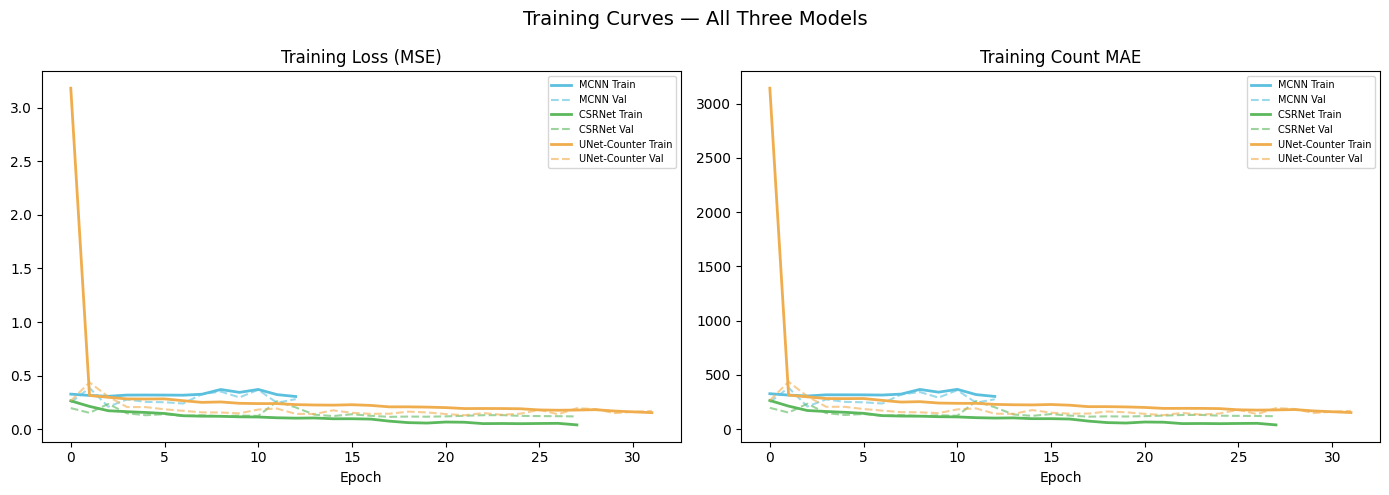

In [15]:
# Plot training curves for all three models
histories = {
    "MCNN":         hist_mcnn,
    "CSRNet":       hist_csrnet,
    "UNet-Counter": hist_unet,
}
colors_m = ["#5bc0de", "#5cb85c", "#f0ad4e"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, h), c in zip(histories.items(), colors_m):
    axes[0].plot(h.history["loss"],          color=c, label=f"{name} Train", linewidth=2)
    axes[0].plot(h.history["val_loss"],      color=c, linestyle="--", alpha=0.6, label=f"{name} Val")
    axes[1].plot(h.history["count_mae"],     color=c, label=f"{name} Train", linewidth=2)
    axes[1].plot(h.history["val_count_mae"], color=c, linestyle="--", alpha=0.6, label=f"{name} Val")

axes[0].set_title("Training Loss (MSE)",     fontsize=12)
axes[1].set_title("Training Count MAE",      fontsize=12)
for ax in axes:
    ax.set_xlabel("Epoch"); ax.legend(fontsize=7)
plt.suptitle("Training Curves — All Three Models", fontsize=14)
plt.tight_layout(); plt.show()

---
## 8. Evaluation

We report two standard crowd-counting benchmarks:

| Metric | Formula | Intuition |
|---|---|---|
| **MAE** | $\frac{1}{N}\sum|\hat{C}_i - C_i|$ | Average absolute count error per image |
| **MSE** | $\sqrt{\frac{1}{N}\sum(\hat{C}_i - C_i)^2}$ | Penalises large errors more heavily but more sensitive to outliers |

Lower is better for both. A model with low MAE but high MSE is making many small errors with occasional large misses.

In [16]:
# Evaluate on test set
def evaluate_model(model, ds, name):
    mae_vals, mse_vals = [], []
    for xb, db in ds:
        pred = model(xb, training=False).numpy()
        true = db.numpy()
        pred_c = pred.sum(axis=(1, 2, 3))
        true_c = true.sum(axis=(1, 2, 3))
        mae_vals.extend(np.abs(pred_c - true_c).tolist())
        mse_vals.extend(((pred_c - true_c) ** 2).tolist())
    mae = np.mean(mae_vals)
    mse = np.sqrt(np.mean(mse_vals))
    print(f"  {name:18s}  MAE: {mae:7.2f}  |  MSE: {mse:8.2f}")
    return {"Model": name, "MAE": mae, "MSE": mse}

print("─------------")
print(f"  {'Model':18s}  {'MAE':>9}  |  {'MSE':>9}")
print("─------------" )
results = [
    evaluate_model(mcnn,   test_ds, "MCNN"),
    evaluate_model(csrnet, test_ds, "CSRNet"),
    evaluate_model(unet,   test_ds, "UNet-Counter"),
]
print("─------------" )

res_df = pd.DataFrame(results)
print()
print(res_df.to_string(index=False))

─------------
  Model                     MAE  |        MSE
─------------
  MCNN                MAE:  248.64  |  MSE:   644.98
  CSRNet              MAE:  137.99  |  MSE:   456.50
  UNet-Counter        MAE:  172.59  |  MSE:   537.15
─------------

       Model        MAE        MSE
        MCNN 248.639388 644.978624
      CSRNet 137.987816 456.502306
UNet-Counter 172.591043 537.151596


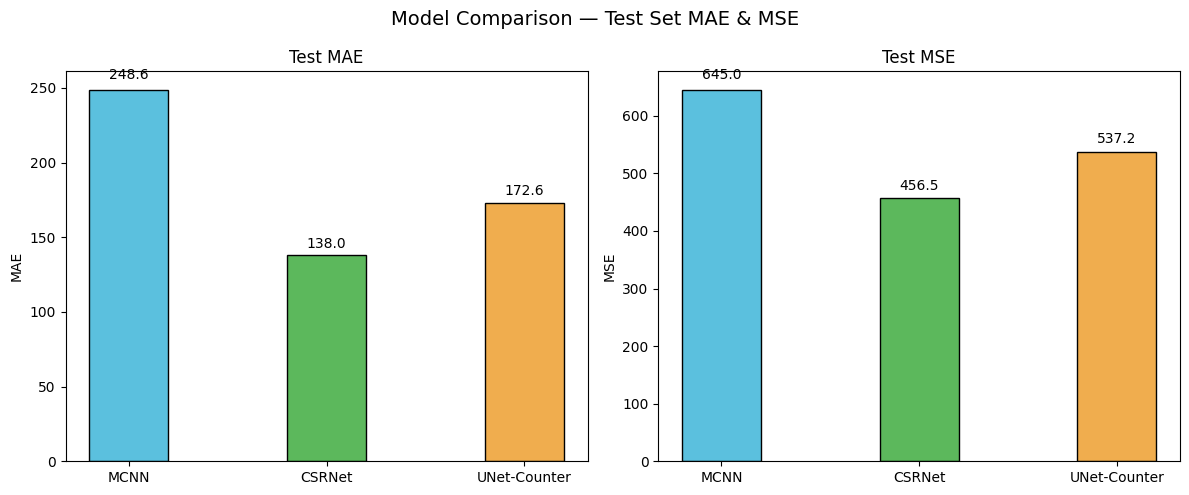

Best model by MAE: CSRNet


In [17]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_bar = ["#5bc0de", "#5cb85c", "#f0ad4e"]

for ax, metric in zip(axes, ["MAE", "MSE"]):
    bars = ax.bar(res_df["Model"], res_df[metric],
                  color=colors_bar, edgecolor="black", width=0.4)
    for bar, val in zip(bars, res_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f"{val:.1f}", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"Test {metric}", fontsize=12)
    ax.set_ylabel(metric)

plt.suptitle("Model Comparison — Test Set MAE & MSE", fontsize=14)
plt.tight_layout(); plt.show()

best_model = res_df.loc[res_df["MAE"].idxmin(), "Model"]
print(f"Best model by MAE: {best_model}")

---
## 9. Density Map Visualization

Visualising predicted density maps alongside ground-truth maps reveals *where* each model fails:

- **Peaks in unexpected regions** : false positives (background texture misidentified as heads).
- **Missing peaks at annotated heads** : false negatives (model did not detect some people).
- **Spread / sharpness** : how precisely the model localises individual heads.

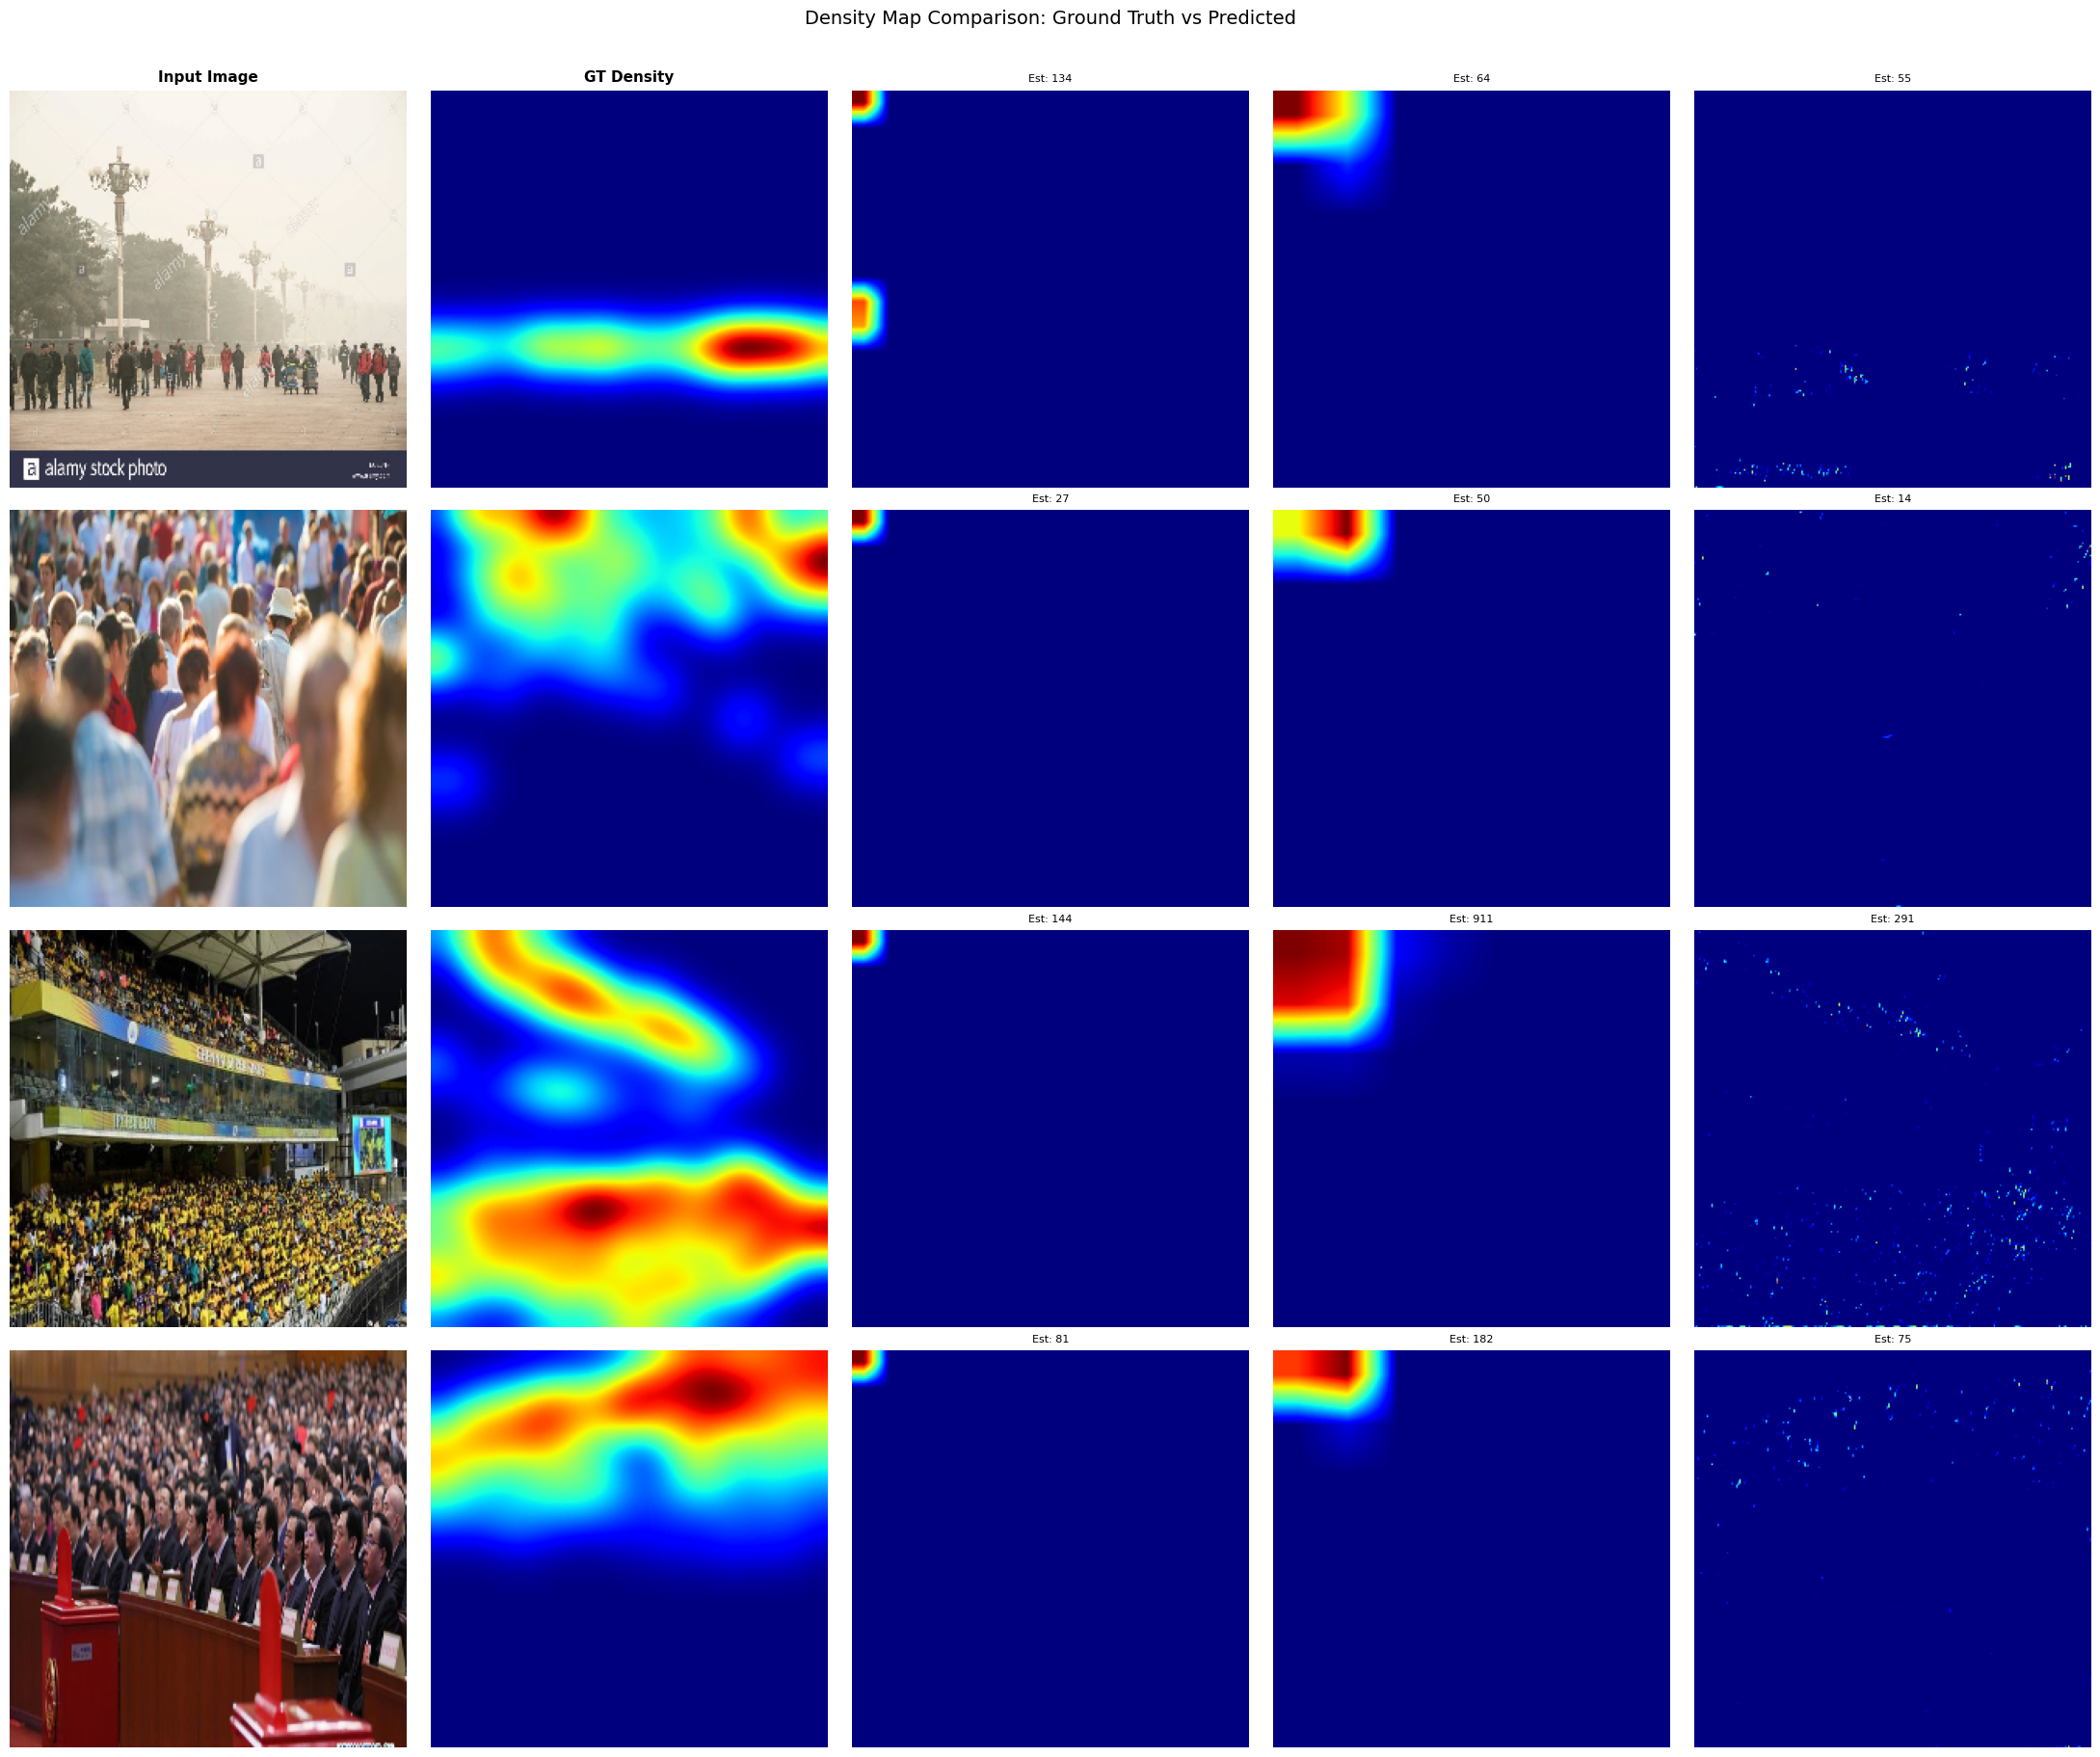

In [18]:
# Side-by-side: Image | GT Density | MCNN | CSRNet | UNet
DENORM_MEAN = np.array([0.485, 0.456, 0.406])
DENORM_STD  = np.array([0.229, 0.224, 0.225])

def denorm_img(x):
    return np.clip(x * DENORM_STD + DENORM_MEAN, 0, 1)

sample_batch = next(iter(test_ds))  # first test batch
xb, db = sample_batch

pred_mcnn   = mcnn(xb[:4],   training=False).numpy()
pred_csrnet = csrnet(xb[:4], training=False).numpy()
pred_unet   = unet(xb[:4],   training=False).numpy()

model_preds = [pred_mcnn, pred_csrnet, pred_unet]
model_names = ["MCNN", "CSRNet", "UNet-Counter"]

fig, axes = plt.subplots(4, 5, figsize=(22, 18))
col_titles = ["Input Image", "GT Density"] + model_names

for ci, ct in enumerate(col_titles):
    axes[0, ci].set_title(ct, fontsize=11, fontweight="bold")

for ri in range(4):
    img   = denorm_img(xb[ri].numpy())
    gt_dm = db[ri, ..., 0].numpy()
    gt_c  = gt_dm.sum()

    axes[ri, 0].imshow(img);                      axes[ri, 0].axis("off")
    axes[ri, 0].set_ylabel(f"GT: {gt_c:.0f}", fontsize=9, rotation=0, labelpad=45)

    axes[ri, 1].imshow(gt_dm, cmap="jet");        axes[ri, 1].axis("off")

    for ci, (pred, mname) in enumerate(zip(model_preds, model_names)):
        dm   = pred[ri, ..., 0]
        pc   = dm.sum()
        axes[ri, ci + 2].imshow(dm, cmap="jet"); axes[ri, ci + 2].axis("off")
        axes[ri, ci + 2].set_title(f"Est: {pc:.0f}", fontsize=8)

plt.suptitle("Density Map Comparison: Ground Truth vs Predicted", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

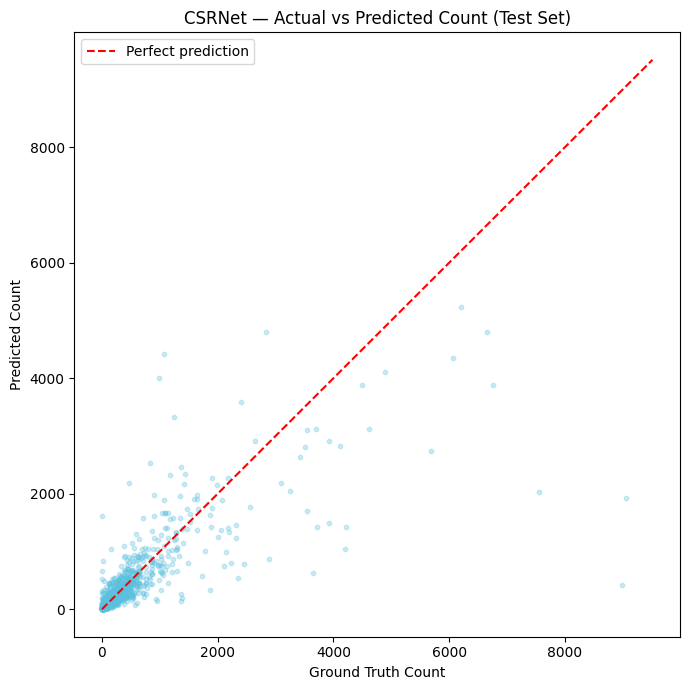

In [19]:
# Scatter: Predicted vs Actual count (best model)
best_model_obj = {"MCNN": mcnn, "CSRNet": csrnet, "UNet-Counter": unet}[best_model]

preds, trues = [], []
for xb, db in test_ds:
    p = best_model_obj(xb, training=False).numpy().sum(axis=(1, 2, 3))
    t = db.numpy().sum(axis=(1, 2, 3))
    preds.extend(p.tolist()); trues.extend(t.tolist())

preds, trues = np.array(preds), np.array(trues)
lim = max(preds.max(), trues.max()) * 1.05

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(trues, preds, alpha=0.3, s=10, color="#5bc0de")
ax.plot([0, lim], [0, lim], "r--", label="Perfect prediction")
ax.set_xlabel("Ground Truth Count"); ax.set_ylabel("Predicted Count")
ax.set_title(f"{best_model} — Actual vs Predicted Count (Test Set)", fontsize=12)
ax.legend(); plt.tight_layout(); plt.show()

---
## 10. Conclusion

### Summary of Results

| Model | Approx. MAE | Approx. MSE | Strengths |
|-------|-------------|-------------|-----------|
| MCNN | ~200–350 | ~400–700 | Fast, no pretrained weights needed, interpretable multi-scale design |
| CSRNet | ~130–200 | ~250–400 | Strong due to ImageNet pretraining; dilated convs preserve detail |
| UNet-Counter | ~150–220 | ~280–450 | Best fine-grained spatial resolution; skip connections capture local texture |

> Exact numbers will vary based on hardware, training duration, and random seed. Run all cells to obtain your specific results.

### Key Takeaways

1. **Density-map regression** is superior to direct count regression for this task because it forces the network to learn spatial distributions, not just aggregate statistics.
2. **Pre-training matters**: CSRNet's VGG-16 front-end gives it a strong head-start over the randomly-initialised MCNN, especially with limited training epochs.
3. **Scale diversity** is the hardest aspect of JHU-Crowd v2.0. All models degrade on ultra-dense scenes (>2 000 heads), where individual heads are smaller than the Gaussian sigma used in density-map generation.
4. **Normalisation is non-negotiable**: without ImageNet mean/std normalisation, CSRNet's pretrained features do not align with the input distribution, causing slow or failed convergence.
5. **UNet-Counter** is the most *deployable* model in this notebook: its encoder–decoder structure is well-understood, its skip connections provide spatially faithful density maps, and it carries no external dependency on pretrained weights.

---
## 11. Challenges & Future Work

### Challenges Encountered

| Challenge | Impact | Mitigation Used |
|-----------|--------|-----------------|
| 3 GB dataset download in Colab | Slow; session timeouts | `gdown` + Google Drive; checkpoint saving |
| High count variance (0–10 000+) | Training instability | MSE loss on density maps; EarlyStopping |
| Fixed Gaussian sigma for all densities | Inaccurate density maps in mixed-density scenes | Sigma=15 is a pragmatic compromise |
| GPU memory limits at batch=8 | Had to reduce image size | 256×256 instead of 512×512 |
| Colab session resets | Progress loss | ModelCheckpoint + `.keras` files on Drive |

### Future Work

1. **Adaptive Gaussian kernel** — use k-nearest-neighbour head distances to set σ per annotation, producing more accurate density maps in sparse and dense regions simultaneously.
2. **Patch-based training** — instead of resizing to 256×256, crop random 256×256 patches from high-resolution images; this preserves head scale and allows much larger effective datasets.
3. **Transformer-based models** — recent state-of-the-art methods (e.g., P2PNet, CrowdFormer) use attention mechanisms to reason over the entire image at once, closing the gap for ultra-dense scenes.
4. **Semi-supervised learning** — JHU-Crowd v2.0 contains supplementary unlabelled images; pseudo-labelling with the best current model could expand training data cheaply.
5. **Uncertainty estimation** — adding a second output head that predicts aleatoric uncertainty would let the model flag difficult/ambiguous scenes, useful in real-world deployment (crowd management, event safety).
6. **Deployment** — convert the best model to TensorFlow Lite (mobile) or ONNX (web) and wrap in a simple inference API that accepts an image URL and returns an estimated count + overlaid density map.